# Training a Computer to Blind Taste Wine (Part I)
> An NLP Application with spaCy and Random Forest Classifier
- toc: true 
- badges: true
- comments: true
- author: Shudi Zhao
- categories: [spaCy, Python, Machine Learning, Data Mining, NLP, RandomForest]
- annotations: true
- image: images
- hide: false

# 1. Introduction

![](my_icons/image1.png)

Introduction paragraph

#  2. Data Cleaning

In [4]:
# packages and methods for data manipulation
import pandas as pd
import numpy as np
from functools import reduce

# function to split data into train and test samples
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# packages for visualization
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
import spacy
nlp = spacy.load("en_core_web_sm")
plt.style.use('seaborn-darkgrid')

In [5]:
a0 = pd.read_csv("mywinedata.csv")
a0.head()

,name,grape_variety,description
0,"Edouard Delaunay 'Septembre' Chardonnay 2019, ...",Chardonnay,"One half of the Abbotts & Delaunay powerhouse,..."
1,The Ned Waihopai River Sauvignon Blanc 2020 Ma...,Sauvignon Blanc,Our bestselling white wine. Winemaker Brent Ma...
2,The Guv'nor,Tempranillo,The Guv'nor is delicious proof that throwing o...
3,E. Guigal Côtes du Rhône 2017,Grenache,The Rhône is one of the most ancient wine regi...
4,The King's Favour Sauvignon Blanc 2019/20 Marl...,Sauvignon Blanc,Brent Marris is winemaking royalty. And it tur...


In [6]:
#Check the value counts for each grape variety
df_val_counts = pd.DataFrame(a0['grape_variety'].value_counts())
df_val_counts.head(10)

,grape_variety
Chardonnay,219
Pinot Noir,101
Cabernet Sauvignon,92
Sauvignon Blanc,91
Grenache,67
Merlot,60
Shiraz,45
Malbec,43
Tempranillo,41
Syrah,29


In [7]:
## removing varieties that have less 80 members in the database
varieties = df_val_counts[df_val_counts['grape_variety'] >= 80].index

data_input = a0[a0['grape_variety'].isin(varieties)].reset_index()

In [8]:
# split the data into train and test
combined_features = ['description', 'grape_variety']
target = 'grape_variety'

X_train, X_test, y_train, y_test = train_test_split(data_input[combined_features], data_input[target], 
                                                    test_size=0.30, random_state=42)

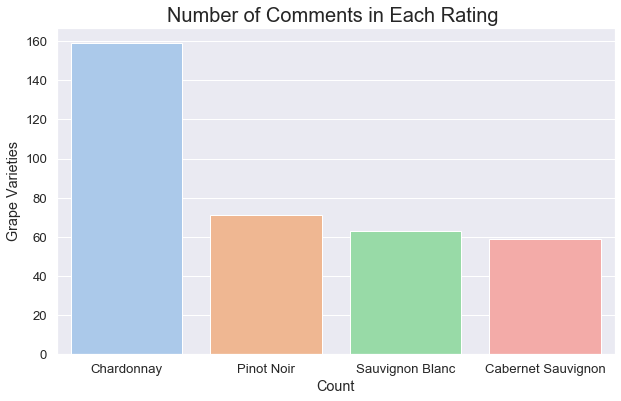

In [9]:
# plotting the number of samples for each grape variety

#set plot theme and font size
sns.set(style="darkgrid", font_scale=1.2)
#Specifiy the figure size 
plt.figure(figsize=(10,6))

ax = sns.countplot(x="grape_variety", data = X_train, palette="pastel", 
                   order = X_train['grape_variety'].value_counts().index)
ax.set_title("Number of Comments in Each Rating ", fontsize=20)
ax.set_xlabel('Count')
ax.set_ylabel('Grape Varieties')
plt.show()

In [10]:
# aggregate description by grape type
grouped = X_train[['grape_variety', 'description']].groupby(['grape_variety']).agg(
    {'description': lambda z: reduce(lambda x,y: ''.join(x+y), z)}
)
grouped["description"] = grouped["description"].str.lower()
grouped.head()

,description
grape_variety,
Cabernet Sauvignon,château livran once belonged to both edward i ...
Chardonnay,produced exclusively from top quality chardonn...
Pinot Noir,you might think california is too hot for the ...
Sauvignon Blanc,this dessert wine from marisco vineyards' king...
